# NB06 — OLS Assumptions: LINE

> **StatQuest: "The math works perfectly... IF these four conditions hold."**

---

## The four assumptions spelled out:

| Letter | Name | Plain-English version |
|--------|------|-----------------------|
| **L** | Linearity | The true relationship is a straight line (not curved) |
| **I** | Independence | Knowing one observation tells you nothing about another |
| **N** | Normality | The errors (residuals) follow a bell curve |
| **E** | Equal variance | The spread of errors is the same everywhere (homoscedasticity) |

If any assumption breaks, OLS estimates are still the best you can do AMONG linear models,
but standard errors and p-values may be wrong.


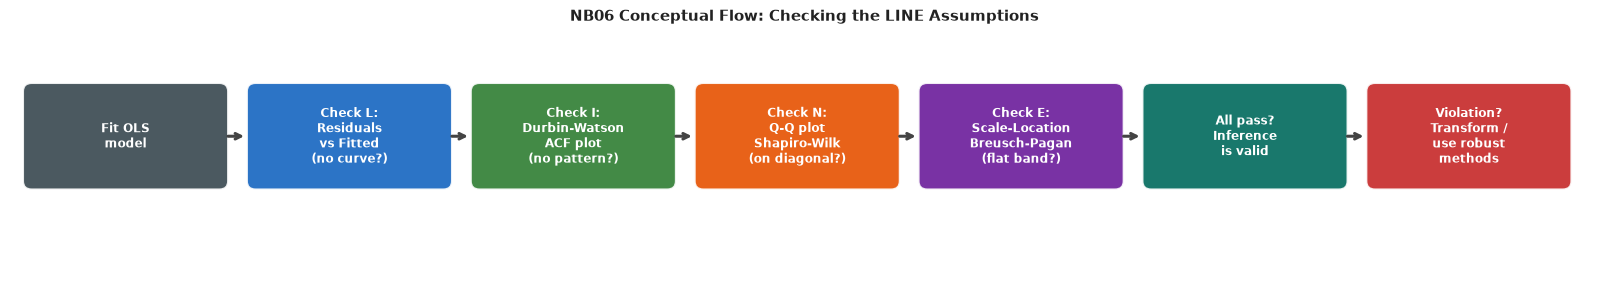

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

def flow_diagram(steps, title, colors=None, notes=None, figsize=(14, 2.8)):
    n = len(steps)
    default_colors = ['#1565C0','#2E7D32','#E65100','#6A1B9A',
                      '#00695C','#AD1457','#37474F','#4E342E',
                      '#0277BD','#558B2F','#C62828','#F57F17']
    colors = (colors or default_colors)[:n]
    notes  = notes or ['']*n
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(-0.3, n*3.1); ax.set_ylim(-1.2, 2.4); ax.axis('off')
    bw, bh = 2.6, 1.3
    for i,(step,color,note) in enumerate(zip(steps,colors,notes)):
        x = i*3.1
        box = FancyBboxPatch((x,0.2),bw,bh,boxstyle="round,pad=0.12",
                             facecolor=color,edgecolor='white',linewidth=1.5,alpha=0.90)
        ax.add_patch(box)
        ax.text(x+bw/2,0.2+bh/2,step,ha='center',va='center',fontsize=8.5,
                color='white',fontweight='bold',multialignment='center')
        if note:
            ax.text(x+bw/2,0.02,note,ha='center',va='top',fontsize=7,
                    color='#555',style='italic')
        if i < n-1:
            ax.annotate('',xy=(x+bw+0.38,0.2+bh/2),xytext=(x+bw+0.08,0.2+bh/2),
                       arrowprops=dict(arrowstyle='->',color='#444',lw=2.2))
    ax.set_title(title,fontsize=11,fontweight='bold',pad=6,color='#222')
    plt.tight_layout(pad=0.4); plt.show()

flow_diagram(
    steps=[
        'Fit OLS\nmodel',
        'Check L:\nResiduals\nvs Fitted\n(no curve?)',
        'Check I:\nDurbin-Watson\nACF plot\n(no pattern?)',
        'Check N:\nQ-Q plot\nShapiro-Wilk\n(on diagonal?)',
        'Check E:\nScale-Location\nBreusch-Pagan\n(flat band?)',
        'All pass?\nInference\nis valid',
        'Violation?\nTransform /\nuse robust\nmethods',
    ],
    title='NB06 Conceptual Flow: Checking the LINE Assumptions',
    colors=['#37474F','#1565C0','#2E7D32','#E65100','#6A1B9A','#00695C','#C62828'],
    figsize=(16, 2.8),
)


## Assumption L — Linearity

**What it means:** the conditional mean of y is a linear function of x.
```
E[y | x] = b0 + b1*x
```

**How it breaks:** if the true relationship is curved (e.g. y = x^2), the linear model will under-predict in the middle and over-predict at the extremes.

**Diagnostic:** residuals vs fitted values plot — look for a CURVED pattern.
**Good sign:** random scatter around zero (no curve).


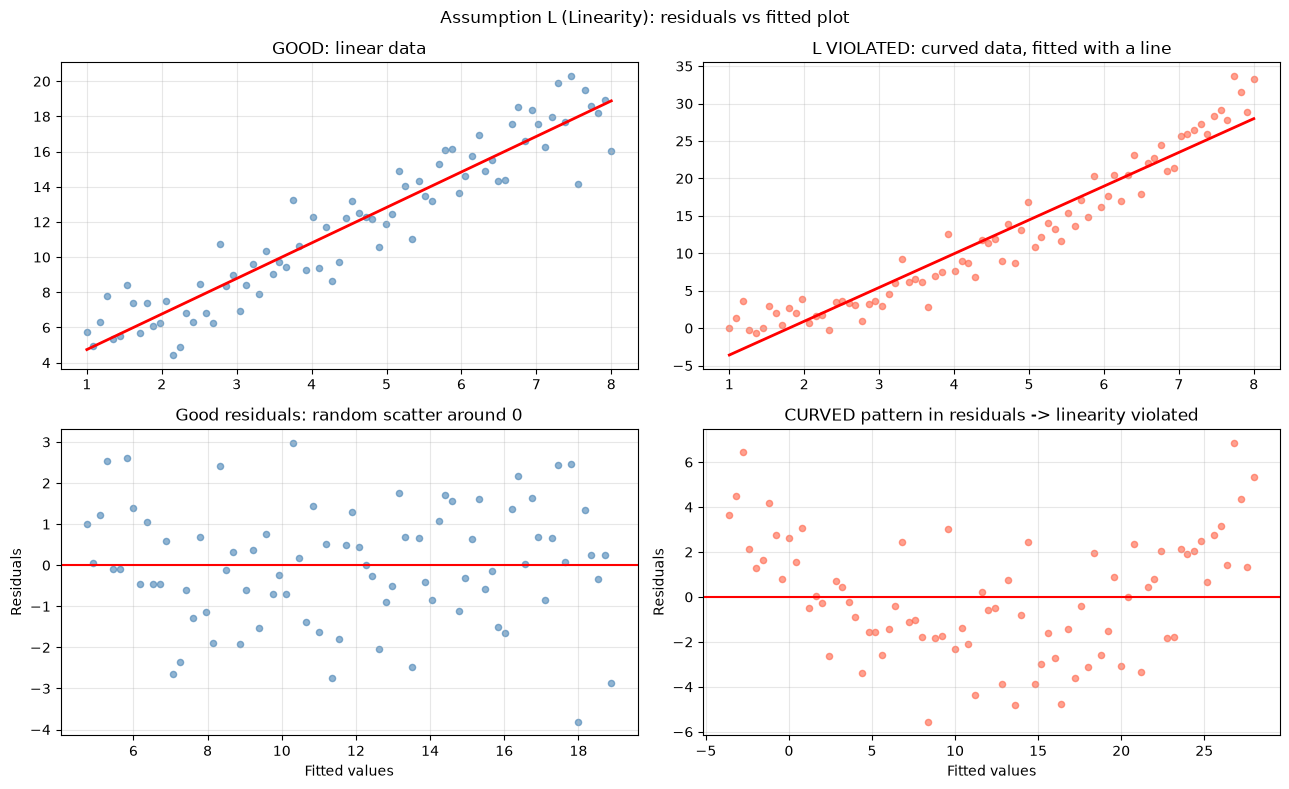

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)
n = 80
X = np.linspace(1, 8, n)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# GOOD: linear data
y_good = 2*X + 3 + np.random.normal(0, 1.5, n)
m_g = LinearRegression().fit(X.reshape(-1,1), y_good)
rg  = y_good - m_g.predict(X.reshape(-1,1))

axes[0,0].scatter(X, y_good, s=20, alpha=0.6, color='steelblue')
axes[0,0].plot(X, m_g.predict(X.reshape(-1,1)), 'r-', linewidth=2)
axes[0,0].set_title('GOOD: linear data'); axes[0,0].grid(alpha=0.3)

axes[1,0].scatter(m_g.predict(X.reshape(-1,1)), rg, s=20, alpha=0.6, color='steelblue')
axes[1,0].axhline(0, color='red', linewidth=1.5)
axes[1,0].set_xlabel('Fitted values'); axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('Good residuals: random scatter around 0'); axes[1,0].grid(alpha=0.3)

# BAD: non-linear data
y_bad = 0.5*X**2 + np.random.normal(0, 2, n)
m_b = LinearRegression().fit(X.reshape(-1,1), y_bad)
rb  = y_bad - m_b.predict(X.reshape(-1,1))

axes[0,1].scatter(X, y_bad, s=20, alpha=0.6, color='tomato')
axes[0,1].plot(X, m_b.predict(X.reshape(-1,1)), 'r-', linewidth=2)
axes[0,1].set_title('L VIOLATED: curved data, fitted with a line'); axes[0,1].grid(alpha=0.3)

axes[1,1].scatter(m_b.predict(X.reshape(-1,1)), rb, s=20, alpha=0.6, color='tomato')
axes[1,1].axhline(0, color='red', linewidth=1.5)
axes[1,1].set_xlabel('Fitted values'); axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('CURVED pattern in residuals -> linearity violated'); axes[1,1].grid(alpha=0.3)

plt.suptitle('Assumption L (Linearity): residuals vs fitted plot', fontsize=12)
plt.tight_layout(); plt.show()


## Assumption I — Independence

**What it means:** knowing one observation's error gives you NO information about another's.

**When it breaks (common):**
- **Time series data:** today's residual is correlated with yesterday's (autocorrelation)
- **Clustered data:** students in the same class, patients at the same hospital
- **Repeated measures:** same person measured multiple times

**Consequence:** standard errors are underestimated -> t-tests are too liberal -> false positives.

**Diagnostic:** Durbin-Watson statistic (want ~2.0), ACF plot of residuals.


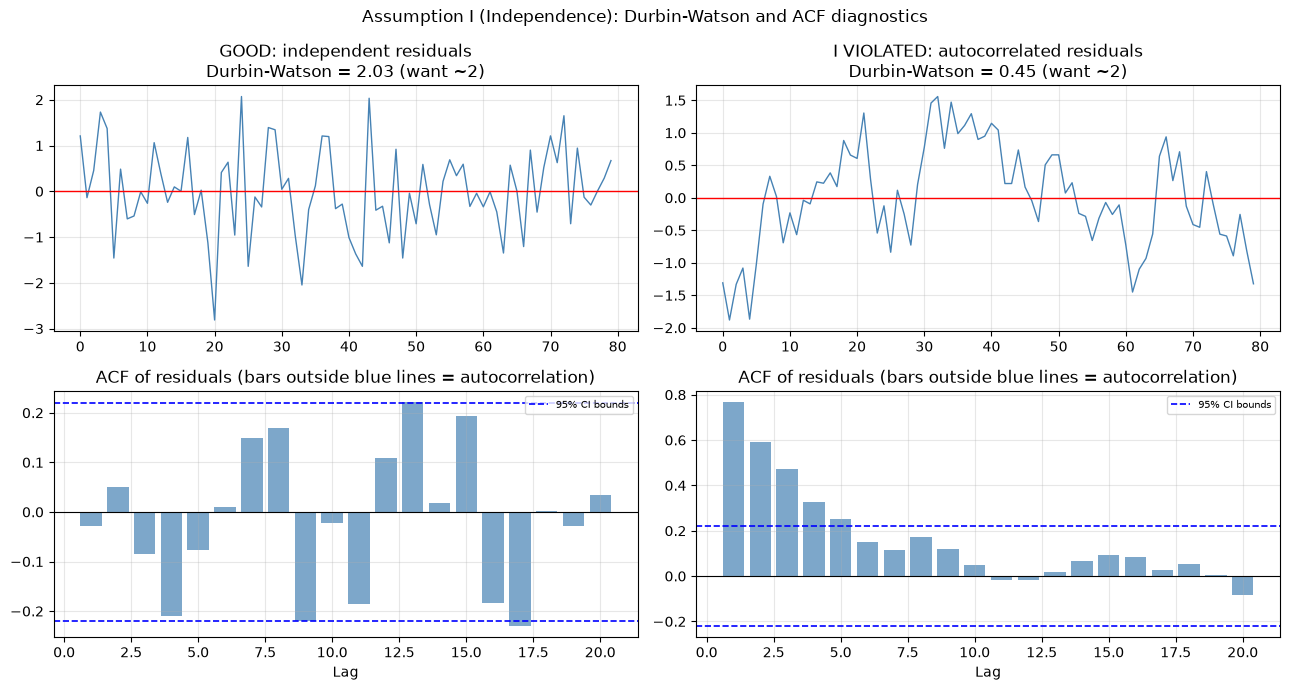

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson

np.random.seed(0)
n = 80
X = np.linspace(0, 10, n)

# Independent residuals (good)
e_ind  = np.random.normal(0, 1, n)
# Autocorrelated residuals (AR1, rho=0.85)
e_auto = np.zeros(n)
for i in range(1, n):
    e_auto[i] = 0.85*e_auto[i-1] + np.random.normal(0, 0.5)

from sklearn.linear_model import LinearRegression

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
for col, (e, title) in enumerate([(e_ind,'GOOD: independent residuals'),
                                   (e_auto,'I VIOLATED: autocorrelated residuals')]):
    y = 2*X + 5 + e
    m = LinearRegression().fit(X.reshape(-1,1), y)
    resid = y - m.predict(X.reshape(-1,1))
    dw = durbin_watson(resid)

    axes[0,col].plot(resid, color='steelblue', linewidth=1)
    axes[0,col].axhline(0, color='red', linewidth=1)
    axes[0,col].set_title(f'{title}\nDurbin-Watson = {dw:.2f} (want ~2)')
    axes[0,col].grid(alpha=0.3)

    # ACF manually
    lags = range(1, 21)
    acf_vals = [np.corrcoef(resid[:-lag], resid[lag:])[0,1] for lag in lags]
    axes[1,col].bar(lags, acf_vals, color='steelblue', alpha=0.7)
    axes[1,col].axhline(0, color='black', linewidth=0.8)
    axes[1,col].axhline(1.96/n**0.5,  color='blue', linewidth=1.2, linestyle='--', label='95% CI bounds')
    axes[1,col].axhline(-1.96/n**0.5, color='blue', linewidth=1.2, linestyle='--')
    axes[1,col].set_title('ACF of residuals (bars outside blue lines = autocorrelation)')
    axes[1,col].set_xlabel('Lag'); axes[1,col].legend(fontsize=7); axes[1,col].grid(alpha=0.3)

plt.suptitle('Assumption I (Independence): Durbin-Watson and ACF diagnostics', fontsize=12)
plt.tight_layout(); plt.show()


## Assumption N — Normality of Residuals

**What it means:** the residuals come from a normal (Gaussian) distribution.

**Why it matters:** the t-test and F-test formulas assume normal residuals.
For large samples (n > 30+), the Central Limit Theorem partially rescues you.
For small samples, non-normality invalidates your p-values.

**Diagnostic:** Q-Q (quantile-quantile) plot — points should lie on a diagonal line.

**StatQuest framing:** "Plot each residual's quantile against what that quantile SHOULD be if the data were normal. Points on the line -> normal."


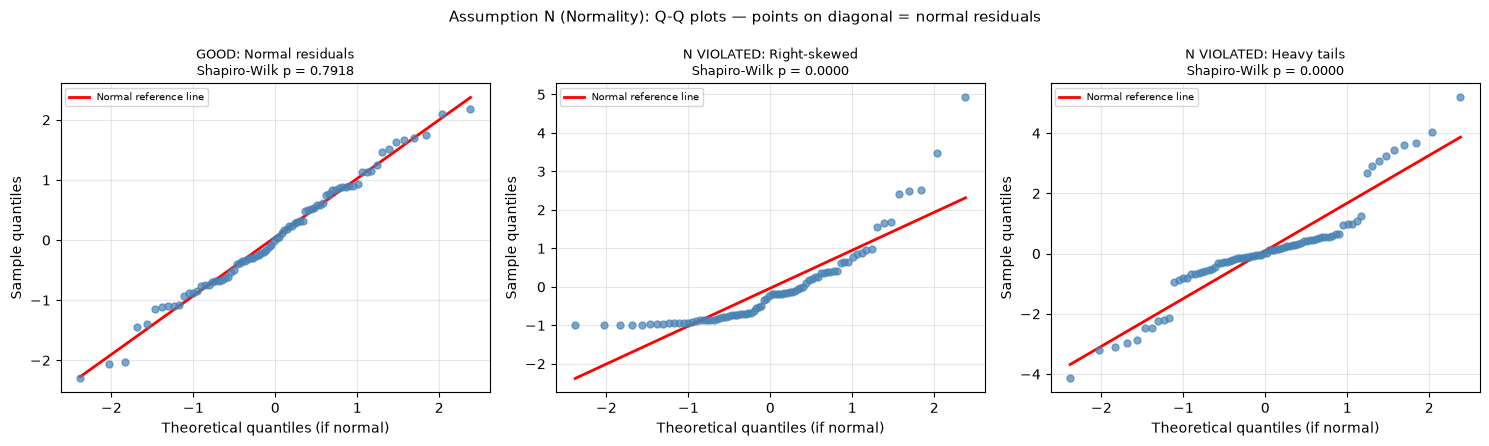

Shapiro-Wilk: p < 0.05 -> reject normality


In [4]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

np.random.seed(1)
n = 80

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
configs = [
    (np.random.normal(0,1,n),              'GOOD: Normal residuals'),
    (np.random.exponential(1,n) - 1,        'N VIOLATED: Right-skewed'),
    (np.concatenate([np.random.normal(-3,1,10), np.random.normal(3,1,10),
                     np.random.normal(0,0.5,60)]),  'N VIOLATED: Heavy tails'),
]

for ax, (residuals, title) in zip(axes, configs):
    (osm, osr), (slope, intercept, r) = stats.probplot(residuals)
    ax.scatter(osm, osr, s=25, color='steelblue', alpha=0.7, zorder=3)
    xs = np.array([osm.min(), osm.max()])
    ax.plot(xs, slope*xs+intercept, 'r-', linewidth=2, label='Normal reference line')
    sw_stat, sw_p = stats.shapiro(residuals)
    ax.set_title(f'{title}\nShapiro-Wilk p = {sw_p:.4f}', fontsize=9)
    ax.set_xlabel('Theoretical quantiles (if normal)'); ax.set_ylabel('Sample quantiles')
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle('Assumption N (Normality): Q-Q plots — points on diagonal = normal residuals',
             fontsize=11)
plt.tight_layout(); plt.show()
print("Shapiro-Wilk: p < 0.05 -> reject normality")


## Assumption E — Equal Variance (Homoscedasticity)

**What it means:** the spread of residuals is the SAME regardless of the fitted value.

**When it breaks (heteroscedasticity):**
- Income data: rich people have more variability in spending
- Size data: larger objects have larger absolute errors
- Time series: volatility clusters

**Consequence:** OLS is still unbiased, but SE is wrong -> invalid t-tests.

**Fix:** log-transform y, Weighted Least Squares (WLS), or use heteroscedasticity-robust standard errors (HC3).


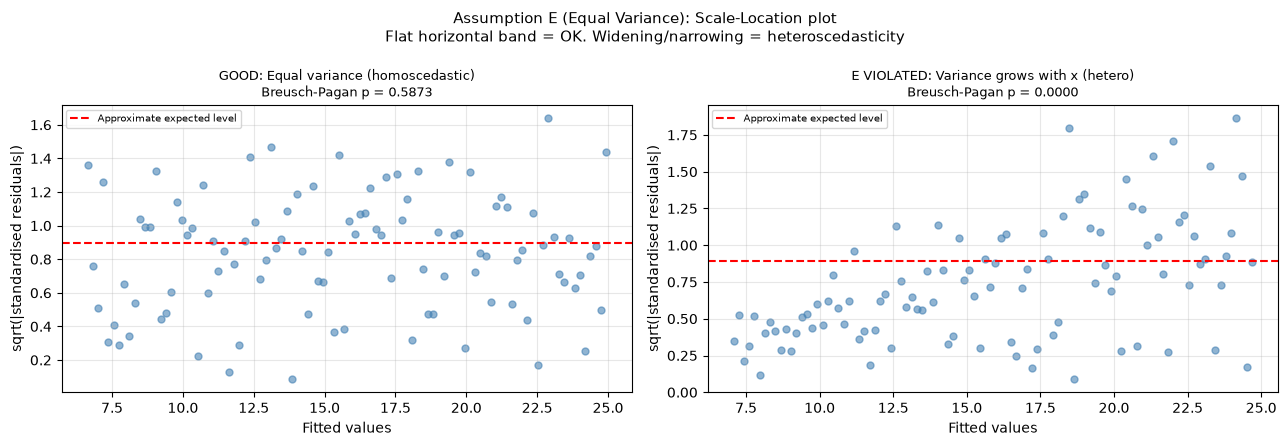

Breusch-Pagan: p < 0.05 -> reject homoscedasticity


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

np.random.seed(3)
n = 100
X = np.linspace(1, 10, n)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
configs = [
    (2*X + 5 + np.random.normal(0, 2, n),            'GOOD: Equal variance (homoscedastic)'),
    (2*X + 5 + np.random.normal(0, 0.4*X, n),        'E VIOLATED: Variance grows with x (hetero)'),
]
for ax, (y, title) in zip(axes, configs):
    Xsm = sm.add_constant(X)
    res = sm.OLS(y, Xsm).fit()
    std_resid = np.sqrt(np.abs(res.resid / (res.resid.std()+1e-10)))
    bp_stat, bp_p, *_ = het_breuschpagan(res.resid, Xsm)
    ax.scatter(res.fittedvalues, std_resid, s=25, alpha=0.6, color='steelblue')
    ax.axhline(np.sqrt(0.8), color='red', linewidth=1.5, linestyle='--',
               label='Approximate expected level')
    ax.set_xlabel('Fitted values'); ax.set_ylabel('sqrt(|standardised residuals|)')
    ax.set_title(f'{title}\nBreusch-Pagan p = {bp_p:.4f}', fontsize=9)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)

plt.suptitle('Assumption E (Equal Variance): Scale-Location plot\n'
             'Flat horizontal band = OK. Widening/narrowing = heteroscedasticity', fontsize=11)
plt.tight_layout(); plt.show()
print("Breusch-Pagan: p < 0.05 -> reject homoscedasticity")


## Summary — What breaks when each assumption fails

| Assumption | What breaks | How bad? | Fix |
|-----------|------------|---------|-----|
| L (Linearity) | Biased coefficients and predictions | SEVERE | Polynomial, log-transform |
| I (Independence) | SE underestimated, too many false positives | SEVERE | Clustered SEs, mixed models |
| N (Normality) | p-values approximate, not exact | MILD for large n | Log/Box-Cox transform |
| E (Equal variance) | SE wrong, invalid t-tests | MODERATE | Robust SEs, WLS |

**Next: NB07 — the four standard diagnostic plots explained in detail.**
